In [6]:
import os
import base64
import json
import random
from openai import OpenAI
import anthropic
import numpy as np
import re
from tqdm import tqdm
import pandas as pd
import time
import matplotlib.pyplot as plt
from word2number import w2n
from dotenv import load_dotenv
import copy

# Load dataset

In [7]:
# Set base directory using relative path
base_dir = os.path.join(os.getcwd(), "dataset", "simpsons")

# Set paths relative to base_dir
annotation_path = os.path.join(base_dir, "v1_Annotation_Val_simpsons_vqa.json")
question_path = os.path.join(base_dir, "v1_Question_Val_simpsons_vqa.json")
images_dir = os.path.join(base_dir, "val_images")

def load_dataset(annotation_path, question_path):
    try:
        with open(annotation_path, 'r') as f:
            annotations = json.load(f)['annotations']

        with open(question_path, 'r') as f:
            questions = json.load(f)['questions']

        # Select high-quality QA pairs (overall_scores == 1.0)
        filtered_annotations = [
            annotation for annotation in annotations
            if annotation.get('overall_scores', {}).get('question') == 1.0 and
               annotation.get('overall_scores', {}).get('answer') == 1.0
        ]

        # Create a mapping from question ID to answer
        question_id_to_answer = {
            annotation['id']: annotation['answer']
            for annotation in filtered_annotations
        }

        # Create a mapping from question ID to answer type
        question_id_to_answer_type = {
            annotation['id']: {
                'answer': annotation['answer'],
                'answer_type': annotation.get('answer_type', 'other')
            }
            for annotation in filtered_annotations
        }

        filtered_questions = [question for question in questions if question['id'] in question_id_to_answer]

        return filtered_questions, filtered_annotations, question_id_to_answer, question_id_to_answer_type

    except Exception as e:
        print(f"Error loading dataset: {e}")
        return [], [], {}, {}

def get_dataset(questions, question_id_to_answer, fraction=0.005, seed=42):
    # TODO：Increase quantity
# def get_dataset(questions, question_id_to_answer, fraction=0.05, seed=42):
    try:
        random.seed(seed)
        sample_size = max(1, int(len(questions) * fraction))
        sampled_question_items = random.sample(questions, sample_size)
        sampled_correct_answers = [
            question_id_to_answer[q['id']]
            for q in sampled_question_items
        ]
        # Add image_base64 to each sampled question
        for q in sampled_question_items:
            image_relative_path = q['img_path']
            image_path = os.path.join(images_dir, image_relative_path)
            q['image_base64'] = encode_image(image_path)

        return sampled_question_items, sampled_correct_answers

    except Exception as e:
        print(f"Error sampling dataset: {e}")
        return [], []

def encode_image(image_path):
    try:
        if not os.path.exists(image_path):
            print(f"Error: The image file at {image_path} was not found.")
            return None

        with open(image_path, "rb") as image_file:
            image_base64 = base64.b64encode(image_file.read()).decode('utf-8')
            return image_base64

    except Exception as e:
        print(f"An error occurred while encoding the image: {e}")
        return None

# Initialize results list
results_ablation = []

# Cache the initial dataset load to avoid repeated disk I/O
cached_dataset = None

# Function to get a fresh copy of the dataset
def get_fresh_dataset(reload=False):
    global cached_dataset
    if cached_dataset is None or reload:
        print("Loading dataset from disk...")
        # Load the dataset from disk
        questions, annotations, question_id_to_answer, question_id_to_answer_type = load_dataset(annotation_path, question_path)
        cached_dataset = {
            'questions': questions,
            'annotations': annotations,
            'question_id_to_answer': question_id_to_answer,
            'question_id_to_answer_type': question_id_to_answer_type
        }
    else:
        print("Using cached dataset but creating a deep copy to prevent contamination...")

    # Always return a deep copy to prevent cross-configuration contamination
    return copy.deepcopy(cached_dataset['questions']), \
           copy.deepcopy(cached_dataset['annotations']), \
           copy.deepcopy(cached_dataset['question_id_to_answer']), \
           copy.deepcopy(cached_dataset['question_id_to_answer_type'])

# Ablation Study Configuration
# Global variables for agent enablement, initialized here
ENABLE_VISUAL_AGENT = False
ENABLE_LANGUAGE_AGENT = False
ENABLE_CRITIC_AGENT = False


# Agents Configuration

In [8]:
load_dotenv()
# Configuration
# MODEL_NAME = "claude-3-5-haiku-20241022"
MODEL_NAME = "gpt-4o-mini"

is_openai_model = not MODEL_NAME.startswith("claude-")

if is_openai_model:
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    print(f"Using OpenAI model: {MODEL_NAME}")
else:
    client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
    print(f"Using Anthropic model: {MODEL_NAME}")

# Agent Implementations

# Enhanced Visual agent that provides highly accurate and question-relevant descriptions
def visual_agent(image_base64, question, max_retries=3, retry_delay=2):
    if not ENABLE_VISUAL_AGENT:
        return "This is a cartoon image from The Simpsons."

    prompt = f"""
    You are a visual analysis expert specialized in interpreting The Simpsons cartoon style. 
    
    Your Task: Focus STRICTLY on answering the question "{question}". Based on the cartoon image, describe ONLY the visual elements that help answer it. Be specific SPECIFIC and CONCISE.
    Generate a short, grounded visual description based on the image and the context below.
    
    Follow these Simpsons-specific guidelines:
    - Limit your description to ONE SENTENCE MAXIMUM.
    - Pay attention to the cartoon style and humor of The Simpsons.
    - DIRECTLY ADDRESS the question being asked - if asked about color, focus on color; if asked about objects, focus on those specific objects.
    - For "what are they doing" questions, PRIORITISE THE ACTION THAT MOST OR ALL CHARACTERS ARE DOING.
    - For "what is/are" questions about objects, FOCUS ON THE MAIN OR MOST PROMINENT OBJECTS VISIBLE — NOT NECESSARILY THE MOST NUMEROUS.
    - When describing scenes or backgrounds, MENTION THE CENTRAL OR DOMINANT STRUCTURES FIRST.

    Optionally mention the following aspects ONLY if they are necessary to answer the question "{question}":
    - Character (if relevant): Describe the character involved.
    - Action (if relevant): State the visible action or posture, like standing or sitting.
    - Spatial (if relevant): Describe spatial features such as background layout, position (e.g., in front, behind), and environment (e.g., room, floor, indoor/outdoor) . Prioritise MAIN structures first.
    - Key Object (if relevant): Mention key objects only if critical.
    - Position (if relevant): Indicate spatial position briefly (e.g., left, right, background).
    - Colour (if relevant): Mention colour details if the question requires it.

    Special Instructions:
    - If the question refers to "man", "woman", "boy", "girl", but the visual evidence does not clearly indicate gender, assume the question refers to the person in focus. Focus on the attribute, NOT gender matching.
    - NEVER output "n/a", "unknown", or "none" as the answer.
    - If unsure, always attempt to provide a plausible answer related to the asked attribute (e.g., hair color, clothing).
        
    Important restrictions:
    - DO NOT include plot speculation or storyline interpretation beyond what is visible.
    - DO NOT include references to episodes or Simpsons lore not visible in the image.
    - DO NOT include: opinions, and subjective language.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url",
                                 "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}},
                            ],
                        }
                    ],
                    max_tokens=500,
                    temperature=0.0,
                )
                visual_description = completion.choices[0].message.content.strip()
                return visual_description
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/jpeg", "data": image_base64}},
                        ]
                    }],
                    max_tokens=500,
                    temperature=0.0,
                )
                visual_description = completion.content[0].text.strip()
                return visual_description

        except Exception as e:
            print(f"Visual agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Visual agent failed to process the image")
    return None

# Language agent: handles questions, and outputs initial predicted answer
# This agent is typically executed FIRST in the agent pipeline
def language_agent(question, image_base64, visual_description, max_retries=3, retry_delay=2):
# If language agent is disabled, return None
    if not ENABLE_LANGUAGE_AGENT:
        return None

    visual_description = visual_description if ENABLE_VISUAL_AGENT else "This is a cartoon image from The Simpsons."

    prompt = f"""
    As a cartoon language expert, answer the "{question}" concisely and accurately based on the provided context using EXACTLY ONE WORD:

    Evidence: 
    Visual Description: "{visual_description}"

    Guidelines: 
    - No explanations or punctuation allowed.
    - Do not answer "none", "n/a", "unknown" even if you are uncertain. Always attempt a plausible reasonable answer.
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {
                                    "type": "image_url",
                                    "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}
                                }
                            ],
                        }
                    ],
                    max_tokens=150,
                    temperature=0.0,
                )
                initial_answer = completion.choices[0].message.content.strip().lower()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                             "source": {"type": "base64", "media_type": "image/jpeg", "data": image_base64}},
                        ]
                    }],
                    max_tokens=150,
                    temperature=0.0,
                )
                initial_answer = completion.content[0].text.strip().lower()

            # Process the response
            # Remove punctuation marks
            initial_answer = initial_answer.rstrip('.!?')

            # Split into words and get the first word
            words = initial_answer.split()
            if not words:
                continue

            initial_answer = words[0]

            # Convert numbers if applicable
            try:
                # Check if word represents a number
                number = w2n.word_to_num(initial_answer)
                initial_answer = str(number)
            except ValueError:
                # Check if contains numeric digits
                matches = re.findall(r'\d+', initial_answer)
                if matches:
                    initial_answer = matches[0]

            return initial_answer

        except Exception as e:
            print(f"Language agent attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
            continue

    print("Error: Language agent failed to generate an answer")
    return None

def classify_question_type(question):
    question_lower = question.lower()

    # Color questions
    if any(word in question_lower for word in ['color', 'what color', 'blue', 'red', 'green', 'yellow', 'black', 'white']):
        return 'color'

    # Counting/numeric questions
    elif any(word in question_lower for word in ['how many', 'count', 'number']):
        return 'counting'

    # Action questions
    elif any(word in question_lower for word in ['doing', 'action', 'what is', 'what are', 'activity']):
        return 'action recognition'

    # Existence questions
    elif any(word in question_lower for word in ['is there', 'are there', 'does', 'do you see', 'can you']):
        return 'existence'

    # Location questions
    elif any(word in question_lower for word in ['where', 'location', 'place', 'position', 'on the', 'in the']):
        return 'location'

    # Default
    return 'other'

def critic_agent(question, image_base64, initial_answer, visual_description, max_retries=3, retry_delay=2, verbose=False):
    # If critic agent is disabled, return the initial prediction
    if not ENABLE_CRITIC_AGENT:
        return initial_answer, False, {}

    # Handle case when language_agent failed or was disabled
    if initial_answer is None:
        return "unknown", False, {}
    
    visual_description = visual_description if ENABLE_VISUAL_AGENT else "This is a cartoon image from The Simpsons."
    force_poor_visual_description_quality = not ENABLE_VISUAL_AGENT
    question_type = classify_question_type(question)
    
    prompt = f"""
    As a cartoon critic expert. Focus on the question "{question}", evaluate the initial answer "{initial_answer}" and provide a confident final answer based on the available evidence.

    Step 1: Assess the Visual Description quality: "{visual_description}"
    - If the description is clear, relevant, and helpful to answer the question, set:
    VISUAL_DESCRIPTION_QUALITY: GOOD  
    - If the description is ambiguous, irrelevant, or misleading, set:
    VISUAL_DESCRIPTION_QUALITY: POOR

    Step 2: Reasoning strategy:
    - If VISUAL_DESCRIPTION_QUALITY is GOOD, consider all available evidence including the visual description "{visual_description}" and image,
    - If VISUAL_DESCRIPTION_QUALITY is POOR, ignore the visual description "{visual_description}" and rely on your own analysis of the image.

    Note: If the VISUAL_DESCRIPTION_QUALITY is GOOD, you may give more weight to it in your decision, but still verify the conclusion with supporting evidence from the image or text.
     Special Instructions:
    - If the question refers to "man", "woman", "boy", "girl", but the visual evidence does not clearly indicate gender, assume the question refers to the person in focus. Focus on the attribute, NOT gender matching.
    - NEVER output "n/a", "unknown", or "none" as the answer.
    - If unsure, always attempt to provide a plausible answer related to the asked attribute (e.g., hair color, clothing).

    Step 3: Use focused reasoning based on question type: "{question_type}":
        - 'color': Check object color and relevance.
        - 'counting': Count visible items.
        - 'action recognition': Describe what characters are doing.
        - 'existence': Confirm object presence.
        - 'location': Analyze positions.
        - 'other': Check general relevance.

    Step 4: Evaluate your confidence in the initial answer "{initial_answer}":
    - MODEL_CONFIDENCE: 1.0 - Very high certainty that initial answer is correct based on clear evidence
    - MODEL_CONFIDENCE: 0.75 - Good confidence that initial answer is correct with supporting evidence
    - MODEL_CONFIDENCE: 0.5 - Moderate confidence in the initial answer
    - MODEL_CONFIDENCE: 0.25 - Low confidence in the initial answer due to unclear or contradictory evidence
    - MODEL_CONFIDENCE: 0.0 - Very uncertain about initial answer, likely incorrect
    
    Based on your confidence level:
    - If MODEL_CONFIDENCE is 0.25 or less, you MUST provide a DIFFERENT answer.
    - If MODEL_CONFIDENCE is high, keep the initial answer unless you have strong evidence against it.

    Respond in the following format:
    MODEL_CONFIDENCE: [1.0 / 0.75 / 0.5 / 0.25 / 0.0]   
    VISUAL_DESCRIPTION_QUALITY: [GOOD / POOR]  
    EXPLANATION: [brief justification]  
    VISUAL_EVIDENCE: [if visual was used, explain which part helped]  
    FINAL_ANSWER: [a single word only]
    """

    for attempt in range(max_retries):
        try:
            if is_openai_model:
                completion = client.chat.completions.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image_url",
                            "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}}
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.choices[0].message.content.strip()
            else:
                completion = client.messages.create(
                    model=MODEL_NAME,
                    messages=[{
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image",
                            "source": {
                                "type": "base64",
                                "media_type": "image/jpeg",
                                "data": image_base64
                            }}
                        ]
                    }],
                    max_tokens=1000,
                    temperature=0.0,
                )
                response = completion.content[0].text.strip()

            # Extract response fields using regex
            visual_description_quality_match = re.search(r'VISUAL_DESCRIPTION_QUALITY:\s*(GOOD|POOR)', response, re.IGNORECASE)
            model_confidence_match = re.search(r'MODEL_CONFIDENCE:\s*(1\.0|0\.75|0\.5|0\.25|0\.0)', response, re.IGNORECASE)
            explanation_match = re.search(r'EXPLANATION:\s*(.+?)(?=\n(VISUAL_EVIDENCE|FINAL_ANSWER)|$)', response, re.IGNORECASE | re.DOTALL)
            visual_evidence_match = re.search(r'VISUAL_EVIDENCE:\s*(.+?)(?=\n(FINAL_ANSWER)|$)', response, re.IGNORECASE | re.DOTALL)
            final_answer_match = re.search(r'FINAL_ANSWER:\s*(.+?)(?=\n|$)', response, re.IGNORECASE)
            
            # Parse the matches to get values
            visual_description_quality = visual_description_quality_match.group(1).upper() if visual_description_quality_match else "POOR"
            model_confidence = float(model_confidence_match.group(1)) if model_confidence_match else 0.5
            explanation = explanation_match.group(1).strip() if explanation_match else "No explanation provided"
            visual_evidence = visual_evidence_match.group(1).strip() if visual_evidence_match else ""
            final_answer_candidate = final_answer_match.group(1).strip().lower().rstrip('.!?') if final_answer_match else initial_answer

            # Override visual quality if visual agent is disabled
            if force_poor_visual_description_quality:
                visual_description_quality = "POOR"
            if verbose and visual_description_quality == "POOR":
                print("Visual description deemed unreliable.")

            # Normalize answers for comparison to detect true content changes (not just formatting differences)
            initial_answer_normalized = initial_answer.rstrip('.!?').lower()
            final_answer_candidate_normalized = final_answer_candidate.rstrip('.!?').lower()
            different = initial_answer_normalized != final_answer_candidate_normalized
            
            # After parsing the model's final answer - expanded list of invalid answers
            invalid_answers = ['n/a', 'unknown', 'none', 'not', 'na', 'nothing', 'invisible', 'unseen', 'unclear']
            if final_answer_candidate_normalized in invalid_answers or 'not visible' in final_answer_candidate_normalized:
                # Force keep the initial answer
                final_answer = initial_answer
                changed = False
                if verbose:
                    print(f"Final answer '{final_answer_candidate}' is invalid. Keeping initial answer '{initial_answer}'.")
            else:
                # Improved decision logic that weighs visual and language information consistently
                if visual_description_quality == "GOOD" and ENABLE_VISUAL_AGENT:
                    # With good visual description, be selective about changes
                    if model_confidence <= 0.5 and different:
                        final_answer = final_answer_candidate
                        changed = True
                        if verbose:
                            print("Good visual quality but low/medium confidence. Changing initial answer.")
                    else:
                        # Trust initial answer when confidence is high
                        final_answer = initial_answer
                        changed = False
                        if verbose:
                            print("Good visual quality with high confidence. Keeping initial answer.")
                else:
                    # Without good visual description, be more critical
                    if model_confidence <= 0.25:
                        final_answer = final_answer_candidate
                        changed = different
                        if verbose:
                            print("Poor visual quality and low confidence. Changing initial answer.")
                    elif model_confidence >= 0.75:
                        final_answer = initial_answer
                        changed = False
                        if verbose:
                            print("Poor visual quality but high confidence. Keeping initial answer.")
                    else:
                        # For medium confidence, still trust initial answer more
                        final_answer = initial_answer
                        changed = False
                        if verbose:
                            print("Poor visual quality with moderate confidence. Keeping initial answer.")

            # Ensure the final answer is a single word/number
            final_answer = final_answer.rstrip('.!?')
            words = final_answer.split()
            if words:
                final_answer = words[0]
            try:
                # Try to convert to number if possible
                number = w2n.word_to_num(final_answer)
                final_answer = str(number)
            except Exception:
                matches = re.findall(r'\d+', final_answer)
                if matches:
                    final_answer = matches[0]

            # Create analysis data dictionary
            analysis_data = {
                'model_confidence': model_confidence,
                'visual_description_quality': visual_description_quality,
                'explanation': explanation,
                'visual_evidence': visual_evidence,
                'changed': changed,
                'initial_answer': initial_answer,
                'final_answer': final_answer
            }

            return final_answer, changed, analysis_data
            
        except Exception as e:
            if verbose:
                print(f"Critic agent error  attempt {attempt + 1} failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                continue

    if verbose:
        print("Critic agent failed after multiple attempts. Returning initial answer.")
    return initial_answer, False, {}



Using OpenAI model: gpt-4o-mini


# Calculate accuracy

In [9]:
def compute_accuracy(question, correct_answer, predicted_answer, answer_type, max_retries=2, retry_delay=2, num_evaluations=3):
    if correct_answer.lower().strip() == predicted_answer.lower().strip():
        return 1.00, [1.00] * num_evaluations

    if correct_answer.lower().strip() + 's' == predicted_answer.lower().strip() or predicted_answer.lower().strip() + 's' == correct_answer.lower().strip():
        return 1.00, [1.00] * num_evaluations
    
    scores = []
    for evaluation_attempt in range(num_evaluations):
        prompt = f"""
        Evaluate the accuracy of the predicted answer according to strict criteria below.

        Input:
        Question: {question}
        Answer type: {answer_type}
        Correct answer: {correct_answer}
        Predicted answer: {predicted_answer}
        
        Evaluation Rules:
        1. Return ONLY a numeric score from [1.0, 0.75, 0.5, 0.25, 0.0].
        2. Answer Type Considerations:
        - Yes/No: Must be exactly correct (1.0) or wrong (0.0)
        - Number: Must be exactly correct (1.0) or wrong (0.0)
        - Other: Focus PRIMARILY on semantic similarity:

        Scoring Criteria:
        - 1.0: Contains the correct core information, even if phrased differently or with additional details
        - 0.75: Mostly correct but missing minor information or containing slight inaccuracies
        - 0.5: Partially correct - contains some correct elements but misses important aspects
        - 0.25: Slightly correct - has a small element of the correct answer but is mostly wrong
        - 0.0: Completely incorrect, contradicts the correct answer, or avoids answering
        """
        
        for attempt in range(max_retries):
            try:
                if is_openai_model:
                    completion = client.chat.completions.create(
                        model=MODEL_NAME,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.choices[0].message.content.strip()
                else:
                    completion = client.messages.create(
                        model=MODEL_NAME,
                        messages=[{
                            "role": "user",
                            "content": prompt
                        }],
                        max_tokens=10,
                        temperature=0.0
                    )
                    response = completion.content[0].text.strip()

                numeric_match = re.search(r'(1\.0|0\.75|0\.5|0\.25|0\.0)', response)
                if numeric_match:
                    score = float(numeric_match.group(1))
                else:
                    score = 0.0

                scores.append(score)
                break

            except Exception as e:
                print(f"Evaluation attempt {evaluation_attempt+1}, retry {attempt+1} failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                    continue
                # If all retries for this evaluation fail, continue to next evaluation

    # If all evaluations failed, return 0
    if not scores:
        return 0.0, []
        
    # Calculate the result using majority voting
    from collections import Counter
    vote_counter = Counter(scores)
    majority_score, count = vote_counter.most_common(1)[0]  # Get most common score
    
    # If there's a tie, calculate average of the tied values
    if len(scores) > 2:  # Only check for ties with more than 2 scores
        top_scores = vote_counter.most_common()
        if len(top_scores) > 1 and top_scores[0][1] == top_scores[1][1]:  # If there's a tie
            # Find all scores with the same count
            tied_scores = [score for score, count in top_scores if count == top_scores[0][1]]
            majority_score = sum(tied_scores) / len(tied_scores)  # Average of tied scores
    
    return majority_score, scores

# Run experiment

In [ ]:
# Run Multiple Configurations
configurations = [
    # Only Language agent
    {
        'visual': False,
        'language': True,
        'critic': False,
        'name': 'language'
    },
    # Visual + Language agents
    {
        'visual': True,
        'language': True,
        'critic': False,
        'name': 'visual_language'
    },
    # Language + Critic agent
    {
        'visual': False,
        'language': True,
        'critic': True,
        'name': 'language_critic'
    },
    # Visual + Language + Critic agent
    {
        'visual': True,
        'language': True,
        'critic': True,
        'name': 'visual_language_critic'
    }
]


def run_experiment(enable_visual, enable_language, enable_critic):
    global ENABLE_VISUAL_AGENT, ENABLE_LANGUAGE_AGENT, ENABLE_CRITIC_AGENT

    printed_analysis_for_questions = set()
    processed_question_ids = set()
    accuracies = []

    # Store original configuration
    original_config = {
        'visual': ENABLE_VISUAL_AGENT,
        'language': ENABLE_LANGUAGE_AGENT,
        'critic': ENABLE_CRITIC_AGENT,
    }

    # Set configuration for this experiment
    ENABLE_VISUAL_AGENT = enable_visual
    ENABLE_LANGUAGE_AGENT = enable_language
    ENABLE_CRITIC_AGENT = enable_critic

    # Create configuration name
    config_parts = []
    if enable_visual:
        config_parts.append("visual")
    if enable_language:
        config_parts.append("language")
    if enable_critic:
        config_parts.append("critic")

    # Define base column order - we'll adjust based on enabled agents
    base_columns = [
        'row_num',
        'question_id',
        'image_path',
        'question',
        'answer_type',
        'correct_answer'
    ]
    
    # Conditionally add columns based on enabled agents
    column_order = base_columns.copy()
    
    if enable_visual:
        column_order.append('visual_description')
        
    if enable_language and enable_critic:
        column_order.extend(['initial_answer', 'predicted_answer'])
    else:
        column_order.append('predicted_answer')
    
    column_order.extend(['evaluator_scores', 'accuracy'])

    try:
        # Initialize results storage
        results = []
        analysis_results = []  
        
        # Load dataset
        questions, annotations, question_id_to_answer, question_id_to_answer_type = get_fresh_dataset()

        if not questions:
            print("The 'questions' list is empty or not a list.")
            raise ValueError("Questions list is empty")

        # Get sample data
        sampled_questions, sampled_correct_answers = get_dataset(questions, question_id_to_answer)

        if not sampled_questions:
            print("Failed to sample questions or empty sample")
            raise ValueError("No sampled questions")

        # Process each question
        for idx, (question_item, correct_answer) in enumerate(tqdm(zip(sampled_questions, sampled_correct_answers),
                                     total=len(sampled_questions))):
            try:
                question_id = question_item['id']
                # Skip if already processed this question
                if question_id in processed_question_ids:
                    continue
                    
                processed_question_ids.add(question_id)
                
                question = question_item['question']
                image_relative_path = question_item['img_path']
                answer_type = question_id_to_answer_type[question_id]['answer_type']

                print(f"\nProcessing question {idx + 1}/{len(sampled_questions)}: ID {question_id}")

                # Build image path and encode
                image_path = os.path.join(images_dir, image_relative_path)
                image_base64 = encode_image(image_path)

                if image_base64 is None:
                    print(f"Skipping question ID {question_id} due to image encoding failure")
                    continue
                
                # Get visual description (will be placeholder if visual agent disabled)
                visual_description = visual_agent(image_base64, question=question)
                if visual_description is None:
                    print(f"Skipping question ID {question_id} - Failed to get image description")
                    continue
                
                # Initialize predicted_answer and initial_answer with default values
                predicted_answer = "unknown"
                initial_answer = "unknown"
                analysis_data = {}
                
                # Handle prediction based on enabled agents
                if enable_language:
                    # Step 1: Always get a pure language answer without visual information
                    # Use a placeholder for visual description to get a "pure language" answer
                    placeholder_description = "This is a cartoon image from The Simpsons."
                    pure_language_answer = language_agent(question, image_base64, placeholder_description)
                    local_accuracies = accuracies if 'accuracies' in globals() and accuracies else []

                    if pure_language_answer is None:
                        print(f"Skipping question ID {question_id} - Failed to generate pure language answer")
                        continue
                    
                    # Step 2: If visual agent is enabled, get a visual-enhanced language answer
                    if enable_visual:
                        visual_language_answer = language_agent(question, image_base64, visual_description)
                        if visual_language_answer is None:
                            print(f"Error for question {question_id} - Failed to generate visual-enhanced answer")
                            visual_language_answer = pure_language_answer  # Fallback to pure language answer
                        initial_answer = visual_language_answer
                    else:
                        # If visual not enabled, use the pure language answer
                        initial_answer = pure_language_answer
                        visual_language_answer = None  
                    
                    # Step 3: Get critic agent improvement if enabled
                    if enable_critic:
                        # Use initial_answer as the base for critic to evaluate
                        final_answer, changed, analysis_data = critic_agent(
                            question=question,
                            image_base64=image_base64,
                            initial_answer=initial_answer,  # Use the appropriate initial answer
                            visual_description=visual_description,
                            verbose=False)  # Set to False to avoid printing in critic_agent

                        # Save critic analysis data for this question
                        if analysis_data and question_id not in printed_analysis_for_questions:
                            # Only print analysis for this question if we haven't printed it before
                            printed_analysis_for_questions.add(question_id)
                            
                            # Extract image filename from path for better identification
                            image_path_basename = os.path.basename(image_path)
                            
                            critic_analysis = {
                                'row_num': len(analysis_results) + 1,
                                'question_id': question_id,
                                'image_path': image_path_basename,
                                'question': question,
                                'answer_type': answer_type,
                                'correct_answer': correct_answer,
                                'initial_answer': initial_answer, 
                                'predicted_answer': final_answer,
                                'model_confidence': analysis_data.get('model_confidence', ''),
                                'visual_description_quality': analysis_data.get('visual_description_quality', ''),
                                'explanation': analysis_data.get('explanation', ''),
                                'visual_evidence': analysis_data.get('visual_evidence', ''),
                                'changed': analysis_data.get('changed', False)
                            }

                            print(f"--- Critic Agent Analysis ---")
                            print(f"- VISUAL_DESCRIPTION_QUALITY: {analysis_data.get('visual_description_quality', 'N/A')}")
                            print(f"- MODEL_CONFIDENCE: {analysis_data.get('model_confidence', 'N/A')}")
                            print(f"- EXPLANATION: {analysis_data.get('explanation', 'N/A')}")
                            print(f"- VISUAL_EVIDENCE: {analysis_data.get('visual_evidence', 'N/A')}")
                            print(f"- INITIAL_ANSWER: {pure_language_answer}")
                            print(f"- FINAL_ANSWER: {final_answer}")
                            print(f"- CHANGED: {changed}")

                            analysis_results.append(critic_analysis)                  
                            predicted_answer = final_answer if final_answer else initial_answer
                        else:
                            predicted_answer = initial_answer
                    else:
                        # When critic is not enabled but language agent is enabled, use the initial answer as the prediction
                        predicted_answer = initial_answer
                            
                # Calculate accuracy
                accuracy, scores = compute_accuracy(
                    question=question,
                    correct_answer=correct_answer,
                    predicted_answer=predicted_answer,
                    answer_type=answer_type
                )

                accuracies.append(accuracy)

                # Store result - create a base result dictionary with all necessary fields
                result = {
                    'question_id': question_id,
                    'image_path': os.path.basename(image_path),
                    'question': question,
                    'answer_type': answer_type,
                    'correct_answer': correct_answer,
                    'predicted_answer': predicted_answer,
                    'evaluator_scores': ", ".join([str(s) for s in scores]),  
                    'accuracy': accuracy
                }
                
                # Conditionally add columns based on which agents are enabled
                if enable_visual:
                    result['visual_description'] = visual_description
                    
                if enable_language and enable_critic:
                    result['initial_answer'] = initial_answer
                    if analysis_data:
                        result['model_confidence'] = analysis_data.get('model_confidence', '')
                        result['visual_description_quality'] = analysis_data.get('visual_description_quality', '')
                        result['explanation'] = analysis_data.get('explanation', '')
                        result['visual_evidence'] = analysis_data.get('visual_evidence', '')
                        result['changed'] = analysis_data.get('changed', False)
                results.append(result)
                
                print(f"Question ID: {question_id}")
                print(f"Image Path: {os.path.basename(image_path)}")
                print(f"Question: {question}")
                print(f"Answer Type: {answer_type}")
                print(f"Correct Answer: {correct_answer}")
                
                # Only display visual description if visual agent is enabled
                if enable_visual:
                    print(f"Visual Description: {visual_description}")
                
                # Only display initial answer if language agent and critic agent are both enabled
                if enable_language and enable_critic:
                    print(f"Initial Answer: {pure_language_answer}")
                    print(f"Predicted Answer: {predicted_answer}")
                else:
                    print(f"Predicted Answer: {predicted_answer}")
                
                print(f"Evaluator Scores: {scores}")
                print(f"Accuracy: {accuracy:.2f}")

            except Exception as e:
                print(f"Error processing question {question_item.get('id', 'unknown')}: {e}")
                continue

        # Add row numbers
        for i, result in enumerate(results, 1):
            result['row_num'] = i

        # Calculate average accuracy
        if accuracies:
            average_accuracy = np.mean(accuracies)
            print(f"Average Accuracy: {average_accuracy:.4f}")
        else:
            print("No valid accuracy data")
            average_accuracy = 0
        
        return results, average_accuracy

    except Exception as e:
        print(f"Unexpected error: {e}")
        average_accuracy = 0
        
        # Restore original configuration
        ENABLE_VISUAL_AGENT = original_config['visual']
        ENABLE_LANGUAGE_AGENT = original_config['language']
        ENABLE_CRITIC_AGENT = original_config['critic']
        
        return [], average_accuracy
    finally:
        ENABLE_VISUAL_AGENT = original_config['visual']
        ENABLE_LANGUAGE_AGENT = original_config['language']
        ENABLE_CRITIC_AGENT = original_config['critic']
        
# Run all ablation experiments sequentially and store results
all_accuracies = {}
all_results = {}

for config in configurations:
    print(f"\n{'='*50}")
    print(f"Running configuration: {config['name']}")
    print(f"{'='*50}")
    results, accuracy = run_experiment(
        enable_visual=config.get('visual', False),
        enable_language=config.get('language', False),
        enable_critic=config.get('critic', False)
    )
    if not results:
        print(f"[Warning] Configuration {config['name']} did not sample any questions or experiment was not executed. Skipping save.")
        continue
    
    print(f"Configuration {config['name']} finished with accuracy: {accuracy:.4f}")
    
    all_accuracies[config['name']] = accuracy
    all_results[config['name']] = results


Running configuration: language
Loading dataset from disk...


  0%|          | 0/36 [00:00<?, ?it/s]


Processing question 1/36: ID 77311


  3%|▎         | 1/36 [00:02<01:24,  2.40s/it]

Question ID: 77311
Image Path: S27E11-05901.jpg
Question: what is on the shelf?
Answer Type: other
Correct Answer: book
Predicted Answer: book
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.00

Processing question 2/36: ID 12809


...

Question ID: 71583
Image Path: S33E13-04701.jpg
Question: what is in the background?
Answer Type: other
Correct Answer: table
Visual Description: The background features a colorful game board with various squares, including images of characters and objects, and a prominent purple bill labeled "LUCRETIA MOTT."
Initial Answer: board
Predicted Answer: board
Evaluator Scores: [0.25, 0.25, 0.25]
Accuracy: 0.25

Processing question 35/36: ID 37083
--- Critic Agent Analysis ---
- VISUAL_DESCRIPTION_QUALITY: GOOD
- MODEL_CONFIDENCE: 1.0
- EXPLANATION: The visual description clearly indicates that one man is gesturing expressively while the other looks concerned, providing strong evidence for the initial answer.
- VISUAL_EVIDENCE: The man on the left is depicted with an expressive gesture, which supports the conclusion that he is indeed gesturing.
- INITIAL_ANSWER: discussing
- FINAL_ANSWER: gesturing
- CHANGED: False
--- Critic Agent Analysis ---
- VISUAL_DESCRIPTION_QUALITY: GOOD
- MODEL_CONF

 97%|█████████▋| 35/36 [06:01<00:09,  9.30s/it]

Question ID: 37083
Image Path: S29E10-27951.jpg
Question: what are the men doing?
Answer Type: other
Correct Answer: standing
Visual Description: The men are standing in front of a red curtain, with one gesturing expressively while the other looks concerned.
Initial Answer: gesturing
Predicted Answer: gesturing
Evaluator Scores: [0.5, 0.5, 0.5]
Accuracy: 0.50

Processing question 36/36: ID 96818


100%|██████████| 36/36 [06:28<00:00, 10.79s/it]

--- Critic Agent Analysis ---
- VISUAL_DESCRIPTION_QUALITY: GOOD
- MODEL_CONFIDENCE: 1.0
- EXPLANATION: The visual description clearly identifies the object as a wooden chair with a distinctive red backrest, which directly answers the question about what the person is sitting on.
- VISUAL_EVIDENCE: The description aligns with the visible elements in the image, confirming the presence of a chair.
- INITIAL_ANSWER: chair
- FINAL_ANSWER: chair
- CHANGED: False
Question ID: 96818
Image Path: S26E21-02601.jpg
Question: what is the person sitting on?
Answer Type: other
Correct Answer: chair
Visual Description: The person is sitting on a wooden chair with a distinctive red backrest, positioned at a dining table.
Initial Answer: chair
Predicted Answer: chair
Evaluator Scores: [1.0, 1.0, 1.0]
Accuracy: 1.00
No valid accuracy data
Configuration visual_language_critic finished with accuracy: 0.0000


# Save results

In [11]:
# Save results for each configuration in the dictionary
for config_name, results_list in all_results.items():
    if not results_list:
        print(f"No results for {config_name}, skipping save.")
        continue
        
    # Clean up results to remove any existing average rows
    results_to_save = [r for r in results_list if r.get('question_id') != 'Average']
    
    # Get unique questions and images for summary
    unique_questions = len(results_to_save)
    unique_images = len(set(r['image_path'] for r in results_to_save))
    
    # Calculate average accuracy
    average_accuracy = all_accuracies.get(config_name, 0)
    
    # Add row numbers to each result
    for idx, result in enumerate(results_to_save, 1):
        result['row_num'] = idx
    
    # Define base column order - standard columns that always appear
    base_columns = [
        'row_num',
        'question_id',
        'image_path',
        'question',
        'answer_type',
        'correct_answer'
    ]
    
    # Determine which optional columns to include based on the configuration name
    column_order = base_columns.copy()
    
    # Visual description is only included if "visual" is in config name
    if "visual" in config_name:
        column_order.append('visual_description')
        
    # Only include both initial and predicted answer if both language and critic are enabled
    if "language" in config_name and "critic" in config_name:
        column_order.extend(['initial_answer', 'predicted_answer'])
    else:
        column_order.append('predicted_answer')
        
    column_order.extend(['evaluator_scores', 'accuracy'])
    
    # Create the average result row with only the necessary columns
    average_result = {
        'row_num': len(results_to_save) + 1,
        'question_id': 'Average',
        'question': '',
        'image_path': '',
        'answer_type': 'All',  
        'correct_answer': f'Total Questions: {unique_questions}, Total Images: {unique_images}',
        'predicted_answer': '',
        'evaluator_scores': '',  
        'accuracy': average_accuracy
    }
    
    # Add conditional columns to the average row
    if "visual" in config_name:
        average_result['visual_description'] = ''
    
    if "language" in config_name and "critic" in config_name:
        average_result['initial_answer'] = ''
        
    results_to_save.append(average_result)
    
    # Save to CSV
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    results_dir = os.path.join(os.getcwd(), "results")
    os.makedirs(results_dir, exist_ok=True)
    
    # Create ablation subdirectory if it doesn't exist
    os.makedirs(os.path.join(results_dir, "ablation"), exist_ok=True)
    
    # Save to ablation subdirectory with configuration in filename
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    output_path = os.path.join(results_dir, "ablation", f'simpsons_ablation_{config_name}_{safe_model_name}_{timestamp}.csv')
    
    # Try to create a DataFrame before file operations
    try:
        results_df = pd.DataFrame(results_to_save)
        
        # Filter to only include columns that exist in our results_df and are in our desired column_order
        filtered_columns = [col for col in column_order if col in results_df.columns]
        results_df = results_df[filtered_columns]
        
        # Check if the file exists and explicitly remove it
        if os.path.exists(output_path):
            try:
                os.remove(output_path)
                print(f"Existing file removed: {output_path}")
            except Exception as e:
                print(f"Error removing existing file: {e}")
        
        # Save the file
        results_df.to_csv(output_path, index=False)
        
        # Verify the file was created
        if os.path.exists(output_path):
            print(f"Results for {config_name} configuration successfully saved to: {output_path}")
        else:
            print(f"Warning: File for {config_name} was not created at {output_path}")
    except Exception as e:
        print(f"Error saving results for {config_name} to CSV: {e}")
        
    # Save detailed analysis data for configurations with critic agent
    if "critic" in config_name:
        analysis_results = []
        changed_count = 0
        
        for result in results_to_save:
            if result.get('question_id') == 'Average':  
                continue
                
            question_id = result.get('question_id', '')
            
            # Core fields that are always present
            analysis_data = {
                'row_num': result.get('row_num', 0),
                'question_id': question_id,
                'image_path': result.get('image_path', ''),
                'question': result.get('question', ''),
                'answer_type': result.get('answer_type', ''),
                'correct_answer': result.get('correct_answer', ''),
                'evaluator_scores': result.get('evaluator_scores', ''),
                'accuracy': result.get('accuracy', 0)
            }
            
            # Add initial and predicted answers if available
            if 'initial_answer' in result and 'predicted_answer' in result:
                analysis_data['initial_answer'] = result.get('initial_answer', '')
                analysis_data['predicted_answer'] = result.get('predicted_answer', '')
                
                # Track if the answer changed
                changed = result.get('initial_answer', '') != result.get('predicted_answer', '')
                analysis_data['changed'] = str(changed)
                if changed:
                    changed_count += 1
            
            # Add critic analysis fields from the original results if they exist
            for field in ['model_confidence', 'visual_description_quality', 'explanation', 'visual_evidence']:
                if field in result:
                    analysis_data[field] = result.get(field, '')
            
            # Use critic analysis data from critic_analysis collection if it's available
            for analysis_item in analysis_results:
                if analysis_item.get('question_id') == question_id:
                    for field in ['model_confidence', 'visual_description_quality', 'explanation', 'visual_evidence', 'changed']:
                        if field in analysis_item and field not in analysis_data:
                            analysis_data[field] = analysis_item[field]
            
            analysis_results.append(analysis_data)

        if analysis_results:
            analysis_dir = os.path.join(results_dir, "analysis")
            os.makedirs(analysis_dir, exist_ok=True)

            analysis_path = os.path.join(analysis_dir, f'simpsons_analysis_{config_name}_{safe_model_name}_{timestamp}.csv')
            avg_confidence = 0

            # Calculate average confidence if available
            confidence_values = [float(r.get('model_confidence', 0)) for r in analysis_results if r.get('model_confidence', '')]
            if confidence_values:
                avg_confidence = sum(confidence_values) / len(confidence_values)
                
            # Create the average row for the analysis file
            average_analysis = {
                'row_num': len(analysis_results) + 1,
                'question_id': 'Average',
                'image_path': '',  
                'question': '',
                'answer_type': 'All',
                'correct_answer': '',
                'initial_answer': '',
                'predicted_answer': '',
                'model_confidence': avg_confidence,
                'visual_description_quality': '',
                'explanation': '',
                'visual_evidence': '',
                'changed': f"{changed_count}/{len(analysis_results)}",
                'evaluator_scores': '',
                'accuracy': average_accuracy
            }
            
            # Create the analysis DataFrame and append the average row
            analysis_df = pd.DataFrame(analysis_results)
            analysis_df = pd.concat([analysis_df, pd.DataFrame([average_analysis])], ignore_index=True)
            
            # Define the column order for the analysis file
            analysis_columns = [
                'row_num', 'question_id', 'image_path', 'question', 'answer_type',
                'correct_answer', 'initial_answer', 'predicted_answer', 'model_confidence',
                'visual_description_quality', 'explanation', 'visual_evidence', 'changed',
                'evaluator_scores', 'accuracy'
            ]
            
            # Filter to only include columns that actually exist
            existing_analysis_columns = [col for col in analysis_columns if col in analysis_df.columns]
            analysis_df = analysis_df[existing_analysis_columns]
            
            # Save the analysis file
            analysis_df.to_csv(analysis_path, index=False)
            print(f"Critic analysis data saved to: {analysis_path}")

Results for language configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_gpt_4o_mini_20250430_194127.csv
Results for visual_language configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_visual_language_gpt_4o_mini_20250430_194127.csv
Results for language_critic configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_language_critic_gpt_4o_mini_20250430_194127.csv
Critic analysis data saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/analysis/simpsons_analysis_language_critic_gpt_4o_mini_20250430_194127.csv
Results for visual_language_critic configuration successfully saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_visual_language_critic_gpt_4o_mini_20250430_194127.csv
Critic analysis data saved to: /Users/wt/PythonProjects/Multi_Agent_C

# Visualization and Comparison


Accuracy values used for visualization:
Language Only: 0.0000
Visual + Language: 0.0000
Language + Critic: 0.0000
Visual + Language + Critic: 0.0000
Visualization saved to: saved_figures/simpsons_ablation_comparison_20250430_194127.png
Visualization saved to: saved_figures/simpsons_ablation_comparison_20250430_194127.png


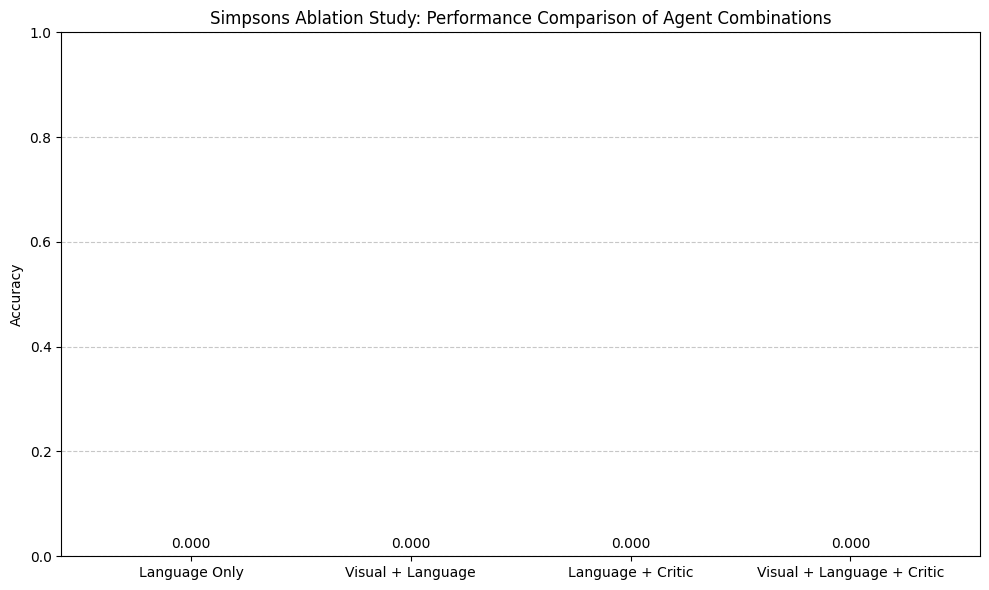


Comparison results saved to: /Users/wt/PythonProjects/Multi_Agent_Cartoon/results/ablation/simpsons_ablation_comparison_20250430_194127.csv
Final comparison data:
                Configuration  Accuracy
0               Language Only         0
1           Visual + Language         0
2           Language + Critic         0
3  Visual + Language + Critic         0


In [12]:
# Create visualization of ablation results
# Check if all_accuracies has values - if not, try to load them from CSV files
if not all_accuracies:
    print("No accuracy results in memory. Attempting to load from CSV files...")
    
    # Define configuration names we expect to find
    expected_configs = [
        'language', 
        'visual_language', 
        'language_critic', 
        'visual_language_critic'
    ]
    
    # Safe model name for file pattern matching
    safe_model_name = MODEL_NAME.replace('-', '_').replace('.', '_')
    # Define results_dir variable here to avoid undefined reference
    base_results_dir = os.path.join(os.getcwd(), "results")
    ablation_results_dir = os.path.join(base_results_dir, "ablation")
    
    # Load accuracies from CSV files if they exist
    for config in expected_configs:
        file_path = os.path.join(ablation_results_dir, f'simpsons_ablation_{config}_{safe_model_name}.csv')
        try:
            if (os.path.exists(file_path)):
                df = pd.read_csv(file_path)
                # Get the last row which should be the Average row
                avg_row = df[df['question_id'] == 'Average']
                if not avg_row.empty and 'accuracy' in avg_row.columns:
                    all_accuracies[config] = float(avg_row['accuracy'].iloc[0])
                    print(f"Loaded accuracy for {config}: {all_accuracies[config]:.4f}")
                else:
                    # Calculate average from individual rows
                    regular_rows = df[df['question_id'] != 'Average']
                    if not regular_rows.empty and 'accuracy' in regular_rows.columns:
                        all_accuracies[config] = float(regular_rows['accuracy'].mean())
                        print(f"Calculated accuracy for {config}: {all_accuracies[config]:.4f}")
        except Exception as e:
            print(f"Error loading results for {config}: {e}")

# If we still don't have accuracy values, use the ones from the notebook state
# Safely access the global accuracies variable if it exists
if 'accuracies' in globals():
    local_accuracies = globals()['accuracies'] if globals()['accuracies'] else []
else:
    local_accuracies = []

if not all_accuracies and local_accuracies:
    # Use the current experiment's results if available
    avg_accuracy = np.mean(local_accuracies) if local_accuracies else 0
    config_name = ''
    if ENABLE_VISUAL_AGENT:
        config_name += 'visual_'
    if ENABLE_LANGUAGE_AGENT:
        config_name += 'language'
    if ENABLE_CRITIC_AGENT:
        config_name += '_critic'
    
    if config_name:
        all_accuracies[config_name] = avg_accuracy
        print(f"Using current experiment accuracy for {config_name}: {avg_accuracy:.4f}")

# Create the results dictionary for visualization
results = {
    "Language Only": all_accuracies.get('language', 0),
    "Visual + Language": all_accuracies.get('visual_language', 0),
    "Language + Critic": all_accuracies.get('language_critic', 0),
    "Visual + Language + Critic": all_accuracies.get('visual_language_critic', 0)
}

# Print the values we're using
print("\nAccuracy values used for visualization:")
for config, accuracy in results.items():
    print(f"{config}: {accuracy:.4f}")

# Create a folder to save figures if not exist
os.makedirs("saved_figures", exist_ok=True)

# Generate timestamp for unique figure name
timestamp = time.strftime("%Y%m%d_%H%M%S")
config_name = f"ablation_comparison_{timestamp}"

# Create the visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('Simpsons Ablation Study: Performance Comparison of Agent Combinations')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure with a unique name
plt.savefig(f"saved_figures/simpsons_{config_name}.png", dpi=300)
print(f"Visualization saved to: saved_figures/simpsons_{config_name}.png")

plt.show()

# Save the comparison results to CSV
comparison_df = pd.DataFrame([results], index=['Accuracy']).T.reset_index()
comparison_df.columns = ['Configuration', 'Accuracy']
timestamp = time.strftime("%Y%m%d_%H%M%S")
comparison_path = os.path.join(os.getcwd(), "results", "ablation", f"simpsons_ablation_comparison_{timestamp}.csv")

# Create results directory if it doesn't exist
os.makedirs(os.path.dirname(comparison_path), exist_ok=True)

# Save the comparison file
comparison_df.to_csv(comparison_path, index=False)
print(f"\nComparison results saved to: {comparison_path}")
print(f"Final comparison data:\n{comparison_df}")